### Imports

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

________

In [2]:
def load_gaze(csv_path):
    df = pd.read_csv(csv_path)

    # Rename for consistency
    df = df.rename(columns={
        'Seconds': 'time',
        'GazeX': 'x',
        'GazeY': 'y'
    })

    # Convert time
    df['time'] = pd.to_datetime(df['time'])

    return df[['time', 'x', 'y']]

In [3]:
gaze_df = load_gaze("/mnt/raid/emotional_data_raquel/supp_mine/gaze/sub-OE002/ses-Hellerup/gaze.csv")
gaze_df.head()

,time,x,y
0,2024-06-27 06:49:20.044713708,684.03870,488.66174
1,2024-06-27 06:49:20.074729708,692.71780,422.27580
2,2024-06-27 06:49:20.080713708,629.63460,352.35130
3,2024-06-27 06:49:20.087721708,582.17580,372.18850
4,2024-06-27 06:49:20.122729708,374.60846,394.04465


In [4]:
gaze_df['dt'] = gaze_df['time'].diff().dt.total_seconds()
print(gaze_df['dt'].describe())

count    44661.000000
mean         0.033314
std          0.028478
min          0.000000
25%          0.020000
50%          0.031008
75%          0.036992
max          0.436000
Name: dt, dtype: float64


min being $0.000 s$ indicates that there are duplicated timestamps
and max being $0.436 s$ means that there is occasional gaps between observations

In [5]:
# Printing duplicated time rows
dup = gaze_df[gaze_df.duplicated(subset='time', keep=False)]
print(dup)

                               time          x         y        dt
1592  2024-06-27 06:50:13.085737708  463.89682  862.9679  0.011008
1593  2024-06-27 06:50:13.085737708  463.89682  862.9679  0.000000
1594  2024-06-27 06:50:13.085737708  463.89682  862.9679  0.000000
44655 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.016000
44656 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44657 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44658 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44659 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44660 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000
44661 2024-06-27 07:14:07.864713708  780.51560  825.3645  0.000000


In [6]:
# Deleting duplicated rows based on above
gaze_df = gaze_df.drop_duplicates(subset='time')

# Check stats again to ensure min value changed
gaze_df['dt'] = gaze_df['time'].diff().dt.total_seconds()
print(gaze_df['dt'].describe())

count    44653.000000
mean         0.033320
std          0.028477
min          0.004992
25%          0.020000
50%          0.031008
75%          0.036992
max          0.436000
Name: dt, dtype: float64


In [7]:
gaze_df.head()

,time,x,y,dt
0,2024-06-27 06:49:20.044713708,684.03870,488.66174,NaN
1,2024-06-27 06:49:20.074729708,692.71780,422.27580,0.030016
2,2024-06-27 06:49:20.080713708,629.63460,352.35130,0.005984
3,2024-06-27 06:49:20.087721708,582.17580,372.18850,0.007008
4,2024-06-27 06:49:20.122729708,374.60846,394.04465,0.035008


Now with no duplicates and good quality data we actually begin the eye tracking part.

_______

In [8]:
def preprocess_gaze(df, x_col='x', y_col='y', time_col='time'):
    df = df.copy()

    # Sort by time
    df = df.sort_values(time_col)

    # Interpolate missing values
    df[x_col] = df[x_col].interpolate(limit=5)
    df[y_col] = df[y_col].interpolate(limit=5)

    # Remove remaining NaNs
    df = df.dropna(subset=[x_col, y_col])

    # Smoothing data with Savitzky-Golay
    if len(df) > 5:
        df['x_smooth'] = savgol_filter(df[x_col], 5, 2)
        df['y_smooth'] = savgol_filter(df[y_col], 5, 2)
    else:
        df['x_smooth'] = df[x_col]
        df['y_smooth'] = df[y_col]

    return df

In [9]:
gaze = preprocess_gaze(gaze_df)
gaze.head()

,time,x,y,dt,x_smooth,y_smooth
0,2024-06-27 06:49:20.044713708,684.03870,488.66174,NaN,678.962928,491.803820
1,2024-06-27 06:49:20.074729708,692.71780,422.27580,0.030016,695.351640,410.818983
2,2024-06-27 06:49:20.080713708,629.63460,352.35130,0.005984,652.187712,367.869272
3,2024-06-27 06:49:20.087721708,582.17580,372.18850,0.007008,538.997040,368.672943
4,2024-06-27 06:49:20.122729708,374.60846,394.04465,0.035008,413.674246,386.541165


Making sure no important data is left behind

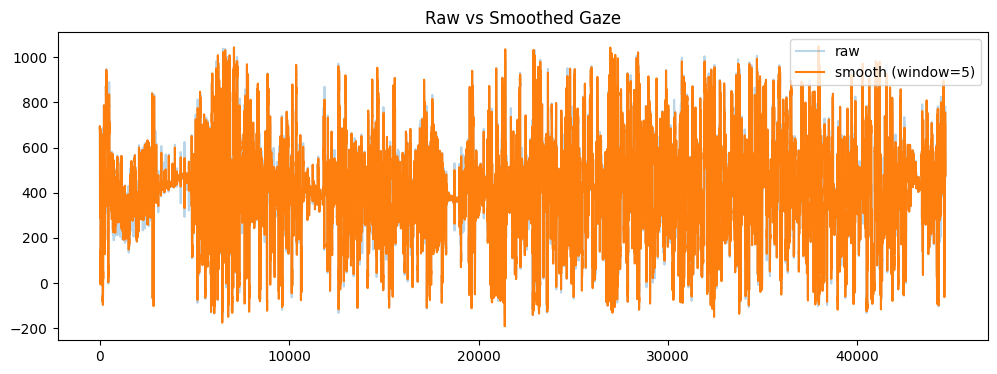

In [10]:
plt.figure(figsize=(12,4))
plt.plot(gaze['x'], alpha=0.3, label='raw')
plt.plot(gaze['x_smooth'], label='smooth (window=5)')
plt.legend()
plt.title("Raw vs Smoothed Gaze")
plt.show()

In [11]:
def compute_velocity(df, time_col='time'):
    df = df.copy()

    # Convert time to seconds
    t_sec = pd.to_datetime(df[time_col]).astype('int64') / 1e9

    # Compute differences
    dt = np.diff(t_sec)
    dx = np.diff(df['x_smooth'])
    dy = np.diff(df['y_smooth'])

    # Avoid division by zero
    dt[dt == 0] = np.nan

    # Compute velocity
    velocity = np.sqrt(dx**2 + dy**2) / dt

    # Add to dataframe
    df['velocity'] = np.nan
    df.iloc[1:, df.columns.get_loc('velocity')] = velocity

    return df

In [12]:
gaze = compute_velocity(gaze)
gaze.head()

,time,x,y,dt,x_smooth,y_smooth,velocity
0,2024-06-27 06:49:20.044713708,684.03870,488.66174,NaN,678.962928,491.803820,NaN
1,2024-06-27 06:49:20.074729708,692.71780,422.27580,0.030016,695.351640,410.818983,2752.752557
2,2024-06-27 06:49:20.080713708,629.63460,352.35130,0.005984,652.187712,367.869272,10175.640925
3,2024-06-27 06:49:20.087721708,582.17580,372.18850,0.007008,538.997040,368.672943,16151.869596
4,2024-06-27 06:49:20.122729708,374.60846,394.04465,0.035008,413.674246,386.541165,3616.040827


In [13]:
gaze['velocity'].describe()

count    44653.000000
mean      1464.534277
std       2338.404587
min          0.000000
25%        241.284255
50%        631.590836
75%       1696.294531
max      46470.783386
Name: velocity, dtype: float64

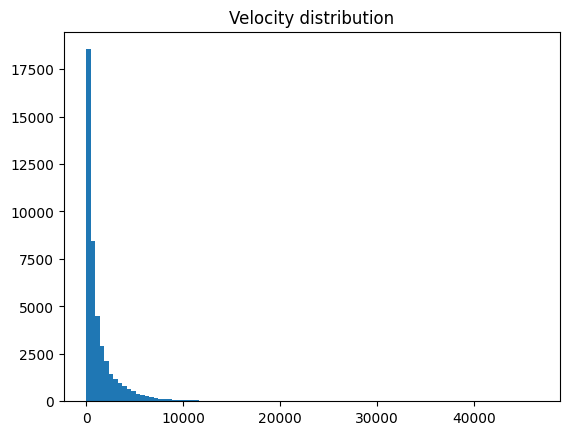

In [14]:
plt.hist(gaze['velocity'].dropna(), bins=100)
plt.title("Velocity distribution")
plt.show()

In [15]:
def classify_ivt(df, threshold=1000):
    df = df.copy()

    df['event'] = 'fixation'
    df.loc[df['velocity'] > threshold, 'event'] = 'saccade'

    return df

In [16]:
gaze = classify_ivt(gaze, threshold=1000)
gaze['event'].value_counts()

event
fixation    27865
saccade     16789
Name: count, dtype: int64

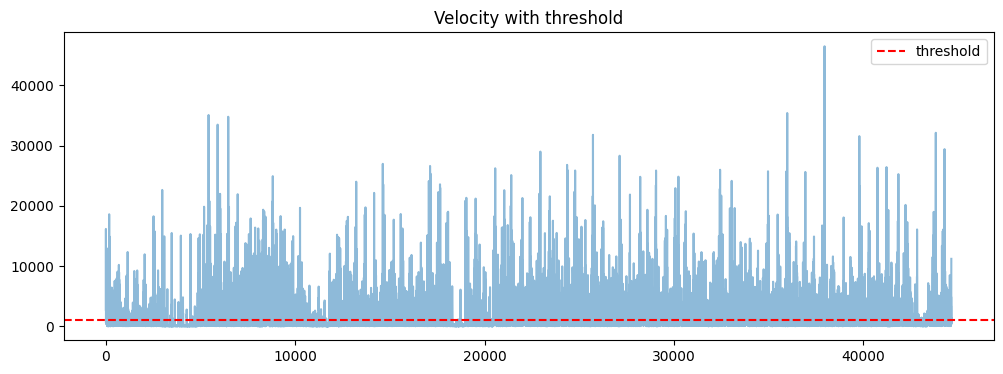

In [17]:
plt.figure(figsize=(12,4))
plt.plot(gaze['velocity'], alpha=0.5)
plt.axhline(1000, color='red', linestyle='--', label='threshold')
plt.legend()
plt.title("Velocity with threshold")
plt.show()

In [18]:
gaze

,time,x,y,dt,x_smooth,y_smooth,velocity,event
0,2024-06-27 06:49:20.044713708,684.03870,488.66174,NaN,678.962928,491.803820,NaN,fixation
1,2024-06-27 06:49:20.074729708,692.71780,422.27580,0.030016,695.351640,410.818983,2752.752557,saccade
2,2024-06-27 06:49:20.080713708,629.63460,352.35130,0.005984,652.187712,367.869272,10175.640925,saccade
3,2024-06-27 06:49:20.087721708,582.17580,372.18850,0.007008,538.997040,368.672943,16151.869596,saccade
4,2024-06-27 06:49:20.122729708,374.60846,394.04465,0.035008,413.674246,386.541165,3616.040827,saccade
...,...,...,...,...,...,...,...,...
44651,2024-06-27 07:14:07.747721708,469.23538,608.26580,0.016992,472.646924,614.141474,1015.513036,saccade
44652,2024-06-27 07:14:07.808713708,492.12430,643.80115,0.060992,495.264811,630.322414,455.960092,fixation
44653,2024-06-27 07:14:07.820713708,532.62990,650.76807,0.012000,505.701261,665.095100,3025.402550,saccade
44654,2024-06-27 07:14:07.848713708,540.71643,732.54570,0.028000,601.488048,730.916267,4150.800962,saccade


________

In [19]:
def extract_fixations(df):
    df = df.copy()

    fixations = []
    current_fix = None

    for i, row in df.iterrows():
        if row['event'] == 'fixation':
            if current_fix is None:
                current_fix = {
                    'start_time': row['time'],
                    'x': [],
                    'y': []
                }

            current_fix['x'].append(row['x'])
            current_fix['y'].append(row['y'])

        else:
            if current_fix is not None:
                end_time = df.loc[i-1, 'time']

                fixations.append({
                    'start_time': current_fix['start_time'],
                    'end_time': end_time,
                    'duration': (end_time - current_fix['start_time']).total_seconds(),
                    'x_mean': np.mean(current_fix['x']),
                    'y_mean': np.mean(current_fix['y'])
                })

                current_fix = None

    return pd.DataFrame(fixations)

In [20]:
fixations = extract_fixations(gaze)
fixations

,start_time,end_time,duration,x_mean,y_mean
0,2024-06-27 06:49:20.044713708,2024-06-27 06:49:20.044713708,0.000000,684.038700,488.661740
1,2024-06-27 06:49:20.190729708,2024-06-27 06:49:20.316713708,0.125984,340.015138,337.364814
2,2024-06-27 06:49:20.419721708,2024-06-27 06:49:20.419721708,0.000000,376.142700,389.921050
3,2024-06-27 06:49:20.686729708,2024-06-27 06:49:20.686729708,0.000000,296.711000,595.981930
4,2024-06-27 06:49:20.786729708,2024-06-27 06:49:20.859721708,0.072992,450.663153,491.086577
...,...,...,...,...,...
5503,2024-06-27 07:14:06.750729708,2024-06-27 07:14:06.929737708,0.179008,258.452292,252.398587
5504,2024-06-27 07:14:07.283721708,2024-06-27 07:14:07.283721708,0.000000,612.400300,537.299260
5505,2024-06-27 07:14:07.593737708,2024-06-27 07:14:07.593737708,0.000000,533.664300,589.195860
5506,2024-06-27 07:14:07.653737708,2024-06-27 07:14:07.717737708,0.064000,502.072860,602.705900


In [21]:
# convert to milliseconds
fixations['duration_ms'] = fixations['duration'] * 1000
# remove short fixations
fixations = fixations[fixations['duration_ms'] >= 100]
fixations

,start_time,end_time,duration,x_mean,y_mean,duration_ms
1,2024-06-27 06:49:20.190729708,2024-06-27 06:49:20.316713708,0.125984,340.015138,337.364814,125.984
8,2024-06-27 06:49:21.456713708,2024-06-27 06:49:21.588713708,0.132000,110.137752,313.486890,132.000
11,2024-06-27 06:49:21.923721708,2024-06-27 06:49:22.218729708,0.295008,218.694784,419.854572,295.008
12,2024-06-27 06:49:22.519721708,2024-06-27 06:49:22.714729708,0.195008,260.338998,309.797797,195.008
14,2024-06-27 06:49:22.894729708,2024-06-27 06:49:23.347721708,0.452992,68.475335,330.539858,452.992
...,...,...,...,...,...,...
5492,2024-06-27 07:14:03.056713708,2024-06-27 07:14:03.917737708,0.861024,617.541214,786.267597,861.024
5497,2024-06-27 07:14:04.783721708,2024-06-27 07:14:05.026729708,0.243008,827.314645,760.062724,243.008
5500,2024-06-27 07:14:05.584713708,2024-06-27 07:14:05.950729708,0.366016,390.385072,259.650397,366.016
5502,2024-06-27 07:14:06.386729708,2024-06-27 07:14:06.615721708,0.228992,94.397087,260.316978,228.992


In [22]:
fixations['duration_ms'].describe()

count     1847.000000
mean       373.882086
std        589.408325
min        100.000000
25%        159.504000
50%        229.024000
75%        372.496000
max      10198.976000
Name: duration_ms, dtype: float64

max now is $10198.976000$ which might be due to a stop or something so I will keep fixations from 100-400 ms max as research mentions.
Although this should not be done, I will keep this 400ms rule to rule out outliners. Like we can see this dataset what a 10198 ms outlier and this rule deletes it :)

In [23]:
fixations = fixations[fixations['duration_ms'] < 4000]
print(fixations['duration_ms'].describe())
print(fixations)

count    1835.000000
mean      338.511828
std       373.352015
min       100.000000
25%       159.008000
50%       228.992000
75%       368.000000
max      3831.008000
Name: duration_ms, dtype: float64
                        start_time                      end_time  duration  \
1    2024-06-27 06:49:20.190729708 2024-06-27 06:49:20.316713708  0.125984   
8    2024-06-27 06:49:21.456713708 2024-06-27 06:49:21.588713708  0.132000   
11   2024-06-27 06:49:21.923721708 2024-06-27 06:49:22.218729708  0.295008   
12   2024-06-27 06:49:22.519721708 2024-06-27 06:49:22.714729708  0.195008   
14   2024-06-27 06:49:22.894729708 2024-06-27 06:49:23.347721708  0.452992   
...                            ...                           ...       ...   
5492 2024-06-27 07:14:03.056713708 2024-06-27 07:14:03.917737708  0.861024   
5497 2024-06-27 07:14:04.783721708 2024-06-27 07:14:05.026729708  0.243008   
5500 2024-06-27 07:14:05.584713708 2024-06-27 07:14:05.950729708  0.366016   
5502 2024-06-27 07